# Lab 07: Credit Card Fraud Detection

---
author: Isabella Iniguez
date: November 6, 2024
embed-resources: true
---

## Introduction

In this report, we develop a classification model that predicts if a given credit card transaction is fraudulent or genuine. By building this model, we aim to work towards an automated fraud detector, aiming to find one that appropriately balances false positives and false negatives.

## Methods

In [33]:
# imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    train_test_split,
)
from pprint import pprint


### Data

In [34]:
# load data
fraud = pd.read_parquet("https://cs307.org/lab-07/data/fraud.parquet")

fraud_train, fraud_test = train_test_split(
    fraud,
    test_size=0.20,
    random_state=42,
    stratify=fraud["Fraud"],
)

fraud_train

,PC01,PC02,PC03,PC04,PC05,PC06,PC07,PC08,PC09,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,Amount,Fraud
57638,-0.514509,0.899378,1.627215,-0.142250,0.005250,-0.235422,0.482540,0.247403,-0.562327,-0.166813,...,-0.143290,-0.390205,0.030719,0.184779,-0.348711,0.073253,0.273217,0.107938,3.59,0
27686,-0.813568,-0.373893,1.152977,-0.449774,-3.868866,2.780636,3.654192,-0.672442,0.753230,-0.662803,...,-0.376783,-0.004239,0.074801,0.124238,-0.448493,0.861423,-0.093639,-0.711632,798.01,0
13321,-2.443142,3.258831,-0.791511,0.223548,0.007932,-1.263044,1.220214,-0.418068,1.860453,4.184883,...,-0.348587,0.531679,0.058990,0.371638,-0.207398,-0.505837,0.524542,-0.343895,1.79,0
28308,-0.397300,0.922104,1.224699,-0.334974,0.322603,-0.117372,0.534683,0.175550,-0.486404,-0.120147,...,-0.239303,-0.695001,-0.128231,-0.536463,-0.138971,0.107526,0.255644,0.100814,2.69,0
54252,1.994046,-0.367813,-0.462867,0.338661,-0.485326,-0.241576,-0.590987,0.089319,1.413224,-0.149292,...,-0.196388,-0.484457,0.421867,0.601393,-0.448014,-0.646256,0.027632,-0.027244,4.49,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49499,-0.033583,-0.487672,1.435406,-2.759369,-1.785638,0.402364,-2.306038,-2.287179,0.129717,-1.036412,...,-1.286823,0.824100,0.018890,0.000018,0.301618,0.081215,0.163422,0.252456,10.00,0
29250,-0.731245,1.151677,0.912393,-0.653540,0.700577,-0.461372,1.093273,-0.126254,-0.339171,-0.467356,...,-0.368185,-0.991854,-0.376461,-0.661608,0.554237,0.450650,0.076395,0.096252,6.99,0
31586,2.135923,-0.714182,-1.842502,-0.587267,0.090754,-0.465733,-0.024834,-0.328747,-0.659832,0.853241,...,-0.537267,-1.081138,0.196589,0.087797,-0.111583,0.479888,-0.082523,-0.053305,64.90,0
14898,-0.335632,0.939736,-2.961515,-1.224739,4.446891,2.352092,0.789725,0.609460,-0.746845,-1.580751,...,-0.002116,0.009686,-0.428325,0.536043,0.278736,0.680976,-0.069295,0.051891,0.76,0


### Data Dictionary

Each observation in the `train` and `test` data contains information about a particular credit card transaction.

The variables considered are:

#### Response
`Fraud`

-   `[int64]` status of the transaction. 1 indicates a fraudulent transaction and 0 indicates not fraud, a genuine transaction.

#### Features
`Amount`

-   `[float64]` amount (in dollars) of the transaction.

`PC01 - PC28`

-   `[float64]` the 28 principal components that encode information such as location and type of purchase while preserving customer privacy.

In [35]:
# summary statistics
print("Number of Samples: ", len(fraud_train))
print("Number of Features: ", len(fraud_train.columns) - 1)

Number of Samples:  54276
Number of Features:  29


In [36]:
# Counts and Proportions
d = fraud_train[['Fraud','Amount']].groupby('Fraud').agg('count').rename(columns={'Amount':'Count'})
d["Proportion"] = d["Count"] / len(fraud_train)
d

,Count,Proportion
Fraud,,
0,53961,0.994196
1,315,0.005804


In [37]:
# Amount Statistics
n = pd.DataFrame([{"Mean": fraud_train['Amount'].mean(), "STD": fraud_train['Amount'].std(), "Median": fraud_train['Amount'].median(), "Maximum": fraud_train['Amount'].max()}])
m = fraud_train[['Fraud','Amount']].groupby('Fraud').agg('mean').rename(columns={'Amount':'Mean'})
s2 = fraud_train[['Fraud','Amount']].groupby('Fraud').agg('std').rename(columns={'Amount':'STD'})
m2 = fraud_train[['Fraud','Amount']].groupby('Fraud').agg('median').rename(columns={'Amount':'Median'})
m3 = fraud_train[['Fraud','Amount']].groupby('Fraud').agg('max').rename(columns={'Amount':'Maximum'})

print(n)
m.join(s2).join(m2).join(m3)

        Mean         STD  Median   Maximum
0  88.197903  241.535617   21.69  10199.44


,Mean,STD,Median,Maximum
Fraud,,,,
0,88.065104,241.451144,21.80,10199.44
1,110.947016,254.978960,6.99,2125.87


In [38]:
# Feature Mean by Fraud Value
fraud_train.groupby('Fraud').agg('mean')

,PC01,PC02,PC03,PC04,PC05,PC06,PC07,PC08,PC09,PC10,...,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,Amount
Fraud,,,,,,,,,,,,,,,,,,,,,
0,0.020248,-0.002301,0.008233,-0.008805,0.007156,-0.001725,0.013265,0.002936,-0.001540,0.014976,...,0.003614,-0.001196,-0.001327,-0.003133,0.002055,0.000950,-0.002467,0.001926,-0.001634,88.065104
1,-4.406446,3.578318,-6.815934,4.570541,-2.880705,-1.315083,-5.440562,0.048049,-2.585855,-5.688388,...,0.390117,0.916146,-0.005732,0.120946,-0.130766,0.030085,0.085179,0.217511,0.082284,110.947016


In [39]:
# Feature Median by Fraud Value
fraud_train.groupby('Fraud').agg('median')

,PC01,PC02,PC03,PC04,PC05,PC06,PC07,PC08,PC09,PC10,...,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,Amount
Fraud,,,,,,,,,,,,,,,,,,,,,
0,0.032412,0.063483,0.169792,-0.018396,-0.051807,-0.275778,0.040079,0.019397,-0.053885,-0.087319,...,-0.063709,-0.029987,0.007817,-0.011842,0.041768,0.018488,-0.053729,0.000562,0.011009,21.80
1,-2.250535,2.726800,-5.076070,4.127549,-1.507035,-1.463272,-2.986028,0.643230,-2.099049,-4.592390,...,0.313332,0.587728,0.083353,-0.048155,-0.145493,0.050678,0.048935,0.421300,0.160769,6.99


<Figure size 1000x800 with 0 Axes>

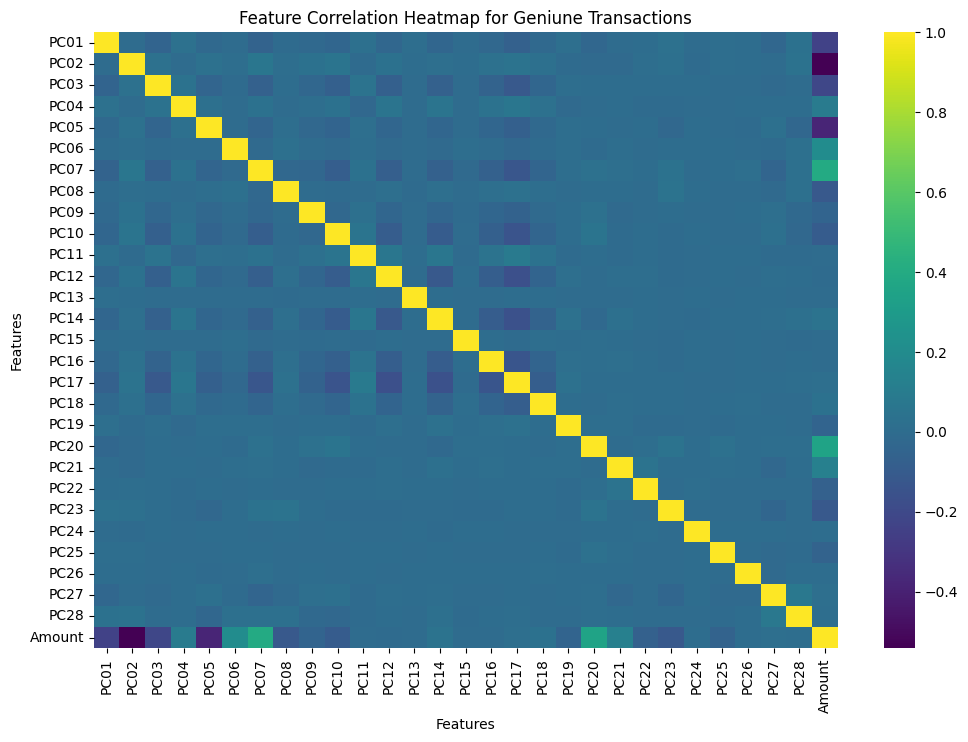

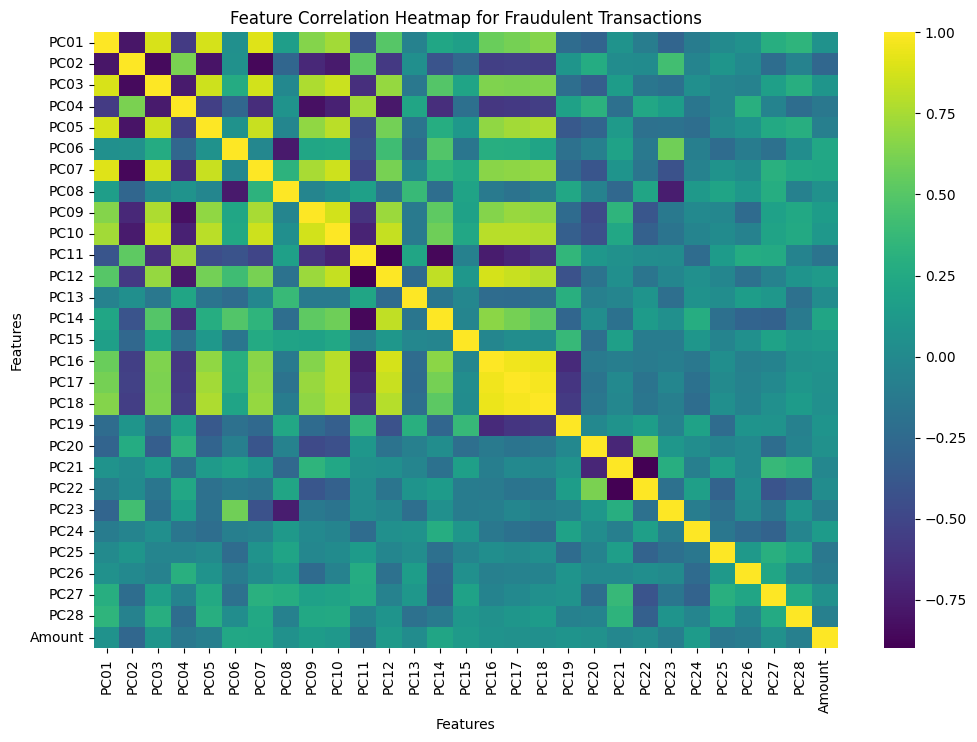

In [ ]:
# visualizations
fraud = fraud_train['Fraud'].unique()
plt.figure(figsize=(10, 8))

for f in fraud:
    f_data = fraud_train[fraud_train['Fraud'] == f]
    feat_data = f_data.loc[:, 'PC01':'Amount']

    plt.figure(figsize=(12, 8))
    sns.heatmap(feat_data.corr(), cmap="viridis", cbar=True)
    if (f==0):
        plt.title(f"Feature Correlation Heatmap for Geniune Transactions")
    else:
        plt.title(f"Feature Correlation Heatmap for Fraudulent Transactions")
    plt.xlabel("Features")
    plt.ylabel("Features")
    plt.show()

When analyzing the data, one of the first things we notice is that we have far less Fraudulent transaction data to reference in comparison to the genuine (only 0.005804 of the data). This may suggest some issues with being able to distinguish between the categories, but since we still have a significant number of these observations (315), it will likely not be as big of a problem.

The visualization of the data, the heatmaps, show an obvious difference in feature correlations between the fraudulent and genuine transactions. The heatmap of genuine transactions shows little to no correlation between the features (outside of with themselves, obviously). However, the heatmap of fraudulent transactions shows frequent, strong correlations between features (particularly with PC0-PC18 with one another). This implies that the relationship between these PC values associated with a particular transaction can be telling of whether a transaction is fraudulent or genuine.


### Models

In [ ]:
# process data for ML
# create X and y for train
X_train = fraud_train.drop("Fraud", axis=1)
y_train = fraud_train["Fraud"]

# create X and y for test
X_test = fraud_test.drop("Fraud", axis=1)
y_test = fraud_test["Fraud"]

In [ ]:
# train models
rf = RandomForestClassifier(random_state=42)

# weights for helping with imbalance
weights_list = [
    {0: 1, 1: 1},
    {0: 1, 1: 3}, # increased from 1:2
    "balanced",
]

# define scoring metrics
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "f1": make_scorer(fbeta_score, beta=3), # increased from beta = 1
}

# Define the parameter grid for the grid search
rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10], 
    "class_weight": weights_list,
}

# Create a GridSearchCV object
rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring=scoring,
    refit="f1",
)

# Fit the grid search object on the training data
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 3},
                                          'balanced'],
                         'max_depth': [5, 10], 'n_estimators': [50, 100]},
             refit='f1',
             scoring={'accuracy': make_scorer(accuracy_score, response_method='predict'),
                      'f1': make_scorer(fbeta_score, response_method='predict', beta=3),
                      'precision': make_scorer(precision_score, response_method='predict', zero_division=0),
                      'recall': make_scorer(recall_score, response_method='predict')})

In [ ]:
# helper function to print cross-validation results
def print_metric_scores(grid, metric):
    cv_results = grid.cv_results_
    best_index = grid.best_index_
    mean_score = cv_results[f"mean_test_{metric}"][best_index]
    std_score = cv_results[f"std_test_{metric}"][best_index]
    print(f"CV {metric} (mean ± std): {mean_score:.3f} ± {std_score:.3f}")

In [ ]:
# print best parameters found and best (cross-validated) score
print(f"Best parameters found with cross-validation:")
pprint(rf_grid.best_params_)
print("")
print_metric_scores(rf_grid, "accuracy")
print_metric_scores(rf_grid, "precision")
print_metric_scores(rf_grid, "recall")
print_metric_scores(rf_grid, "f1")

Best parameters found with cross-validation:
{'class_weight': 'balanced', 'max_depth': 5, 'n_estimators': 100}

CV accuracy (mean ± std): 0.997 ± 0.001
CV precision (mean ± std): 0.748 ± 0.063
CV recall (mean ± std): 0.860 ± 0.039
CV f1 (mean ± std): 0.847 ± 0.034


Here we used a tuning pipeline to try and find the best cross-validated random forest classifier model.

## Results

In [ ]:
# report model metrics
y_pred = rf_grid.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = fbeta_score(y_test, y_pred, beta=1)

y_pred = rf_grid.predict(X_test)
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")

Test Accuracy: 0.9976416832485814
Test Precision: 0.7701149425287356
Test Recall: 0.8481012658227848
Test F1 Score: 0.8072289156626506


The selected model achieves a test precision of 0.770 and test recall of 0.848.

## Discussion

Given that the model achieved a test precision of 0.770 and test recall of 0.848, this model appears to be a decently good detector of fraudulent transactions. However, we have to acknowledge what we have been prioritizing in terms of the model's performance.

This model’s good performance is based on the performance cutoffs we established for this lab, being that we wanted the model to reach a minimum test precision of 0.7 and test recall of 0.83. These numbers suggest that recall is more important, which I agree with.

In the context of this model’s use, recall is more important than precision because missing a fraudulent transaction (false negative) can lead to financial and reputational costs to the banking institution. However, not accounting enough for precision can result in unnecessary disruptions to genuine customers due to incorrect fraudulent flags (false positives). Ultimately, reducing false positives does not help us much if we ultimately can not minimize false negatives (which are arguably more damaging to a client and institution). So a balance of precision and recall is essential for a real-world model that both reduces financial losses and maintains customer trust.

### Conclusion

Given the performance, I would reccomend this model for use.

In [ ]:
from joblib import dump
dump(rf_grid, "credit-fraud.joblib")

['credit-fraud.joblib']